<a href="https://colab.research.google.com/github/JonPaulBIlbao/ML-Finance-DBS/blob/Machine-Learning-in-Finance-DBS/Titanic_Colab_R_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Machine Learning in Finance**
**Deusto Business School**

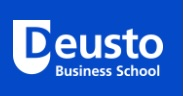

ADE + FAB

---

# 🛳️ **Titanic Survival Prediction in R**

This notebook implements a machine learning pipeline using CHAID decision tree to predict survival on the Titanic dataset. The code is written in **R** and follows a structured teaching format.

This [Kaggle website](https://www.kaggle.com/competitions/titanic) will introduce you the permanent machine learning competition where students from all over the world participate!

> 💬 *Why Titanic?*
>
> While this dataset is not strictly financial, it plays a unique role in this course.
> Students all over the world start their journey into machine learning with this dataset. It becomes a shared reference point, much like the Iris dataset did for generations of statisticians.
>
> Starting with Titanic is like learning your first scales in music: basic, universal, and strangely emotional.


## 1. **Setup and Package Installation**

To get started, we install and load the R packages needed for this analysis.

- We’ll use `CHAID` to build our decision tree.
- `ggplot2` will help us create visualizations.
- Additional base packages like `partykit` and `grid` are needed for CHAID to work properly.

📦 If a package isn’t already installed, the script will take care of it automatically.


In [46]:
required_packages <- c("ggplot2")
missing <- required_packages[!(required_packages %in% installed.packages()[,"Package"])]
if (length(missing)) install.packages(missing)
invisible(lapply(required_packages, library, character.only = TRUE))
cat("Loaded packages:", paste(required_packages, collapse = ", "), "\n")

Loaded packages: ggplot2 


In [47]:
# Install devtools to download from R-Forge
install.packages("devtools")
library(devtools)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [48]:
install.packages("partykit")
library(partykit)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [49]:
devtools::install_url("https://r-forge.r-project.org/src/contrib/CHAID_0.1-2.tar.gz",
                      repos = NULL, type = "source")

Skipping 1 packages not available: partykit



── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/Rtmp67r27e/remotes10d740cedc0/CHAID/DESCRIPTION’ ... OK
* preparing ‘CHAID’:
* checking DESCRIPTION meta-information ... OK
* running ‘cleanup’
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘CHAID_0.1-2.tar.gz’



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [50]:
library(CHAID)

## 2. 🎓 **Titanic Survival Prediction using CHAID Decision Trees**

Welcome to this teaching demonstration based on the Titanic Machine Learning Competition dataset.

In this short session, we will:
- Explore the **Titanic dataset**, a classic for binary classification tasks.
- Understand how to apply the **CHAID decision tree algorithm**, a technique well-suited for categorical explanatory variables.
- Interpret the resulting **decision tree** and how it helps us predict passenger survival.



## 🧠 Why CHAID?

While many machine learning models (like logistic regression or CART trees) are commonly used for classification, **CHAID** offers a distinct advantage when dealing with **categorical predictors**:

- It uses **Chi-square tests** to determine the best splits.
- It **merges categories** that are statistically similar — useful for interpretable results.
- It **does not require pruning** — the algorithm stops when splits are no longer significant.

This makes CHAID particularly **transparent and intuitive** — ideal for teaching how decision rules emerge from data.

---

## ⚙️ Learning Objectives

By the end of this notebook, you should be able to:

✅ Understand the structure of the Titanic dataset  
✅ Fit a CHAID decision tree in R  
✅ Interpret the logic and output of the CHAID model  
✅ Use the model to predict survival and evaluate results

---

Let’s begin by loading the data and preparing it for modeling!

## 3. **Loading and Exploring the Titanic Training Data**

We begin by loading the training dataset provided for the Titanic Machine Learning Competition.

This dataset includes demographic and travel-related information for 891 passengers, along with the **target variable `Survived`** indicating whether each passenger lived (1) or died (0).

We'll take a first look at its structure to understand:
- The types of variables available
- Any potential issues with missing or messy data
- Which variables might be useful predictors for survival

> ⚠️ *A Note on Responsibility*
>
> Remember that each row in this dataset represents a person who went through a terrifying, traumatic experience. These are not just numbers.
>
> In the future, when you work with sensitive data — health records, customer information, personal histories — **do so with respect**.  
>
> **Data always carries a story.**


In [51]:
# 📥 Load Titanic training data from GitHub
titanic_train <- read.csv(
  "https://raw.githubusercontent.com/JonPaulBIlbao/ML-Finance-DBS/Machine-Learning-in-Finance-DBS/decision_trees/train.csv",
  stringsAsFactors = TRUE  # Automatically convert character columns to factors
)

# 📊 Summarize dataset: gives a quick overview of distributions and missing values
summary(titanic_train)

# 🔍 Inspect the structure: check variable types and factor levels
str(titanic_train)

  PassengerId       Survived          Pclass     
 Min.   :  1.0   Min.   :0.0000   Min.   :1.000  
 1st Qu.:223.5   1st Qu.:0.0000   1st Qu.:2.000  
 Median :446.0   Median :0.0000   Median :3.000  
 Mean   :446.0   Mean   :0.3838   Mean   :2.309  
 3rd Qu.:668.5   3rd Qu.:1.0000   3rd Qu.:3.000  
 Max.   :891.0   Max.   :1.0000   Max.   :3.000  
                                                 
                                    Name         Sex           Age       
 Abbing, Mr. Anthony                  :  1   female:314   Min.   : 0.42  
 Abbott, Mr. Rossmore Edward          :  1   male  :577   1st Qu.:20.12  
 Abbott, Mrs. Stanton (Rosa Hunt)     :  1                Median :28.00  
 Abelson, Mr. Samuel                  :  1                Mean   :29.70  
 Abelson, Mrs. Samuel (Hannah Wizosky):  1                3rd Qu.:38.00  
 Adahl, Mr. Mauritz Nils Martin       :  1                Max.   :80.00  
 (Other)                              :885                NA's   :177    
     Sib

'data.frame':	891 obs. of  12 variables:
 $ PassengerId: int  1 2 3 4 5 6 7 8 9 10 ...
 $ Survived   : int  0 1 1 1 0 0 0 0 1 1 ...
 $ Pclass     : int  3 1 3 1 3 3 1 3 3 2 ...
 $ Name       : Factor w/ 891 levels "Abbing, Mr. Anthony",..: 109 191 358 277 16 559 520 629 417 581 ...
 $ Sex        : Factor w/ 2 levels "female","male": 2 1 1 1 2 2 2 2 1 1 ...
 $ Age        : num  22 38 26 35 35 NA 54 2 27 14 ...
 $ SibSp      : int  1 1 0 1 0 0 0 3 0 1 ...
 $ Parch      : int  0 0 0 0 0 0 0 1 2 0 ...
 $ Ticket     : Factor w/ 681 levels "110152","110413",..: 524 597 670 50 473 276 86 396 345 133 ...
 $ Fare       : num  7.25 71.28 7.92 53.1 8.05 ...
 $ Cabin      : Factor w/ 148 levels "","A10","A14",..: 1 83 1 57 1 1 131 1 1 1 ...
 $ Embarked   : Factor w/ 4 levels "","C","Q","S": 4 2 4 4 4 3 4 4 4 2 ...


### 🔍 Quick Observations from the Summary

- `Survived` is coded as **0 (died)** and **1 (survived)**, with about **38% survival rate** (Mean = 0.38).
- `Pclass` (passenger class) ranges from 1 (first class) to 3 (third class), with the median being 3 — indicating that **most passengers traveled in third class**.
- `Sex` is a balanced categorical variable with more males (577) than females (314).
- `Age` contains **177 missing values**, so we’ll need to decide how to handle that if it’s used later.
- `Fare` varies widely, up to **£512**, suggesting large disparities in ticket pricing.
- `Cabin` has many missing entries (687 out of 891), limiting its direct use in modeling unless recoded (e.g., by deck).
- `Embarked` indicates the **port where each passenger boarded**:
  - **S** = Southampton (UK) – the ship's **main departure port**  
  - **C** = Cherbourg (France)  
  - **Q** = Queenstown (now Cobh, Ireland)  
  While Queenstown was the final stop before crossing the Atlantic, most passengers (644 out of 891) boarded at **Southampton**.
- `SibSp` and `Parch` represent family relationships aboard:
  - `SibSp` counts the number of **siblings and/or spouses** a passenger had on board.
  - `Parch` counts the number of **parents and/or children** traveling with the passenger.  
  Most passengers had **no relatives with them** (i.e., both values are 0).

These observations guide:
- Which variables may be **predictive** (e.g. `Sex`, `Pclass`, `Embarked`)
- Which may require **preprocessing** (e.g. handling NAs in `Age`, possible exclusion of `Cabin`)


## 4. 🧹**Data Readiness and Early Exploration: Sex and Survival**

Before modeling, it's useful to explore how **categorical variables relate to the outcome**.  
Here, we focus on `Sex`, one of the most predictive features in this dataset.

We will:
- Inspect the contingency table between `Survived` and `Sex`
- Run a **Chi-squared test** to assess statistical association
- Calculate **row-wise percentages** to understand survival rates by sex

In [52]:
# Ensure Survived is a factor with specified levels and labels
titanic_train$Survived <- factor(titanic_train$Survived, levels = c(0, 1), labels = c("Died", "Survived"))

# Check data structure
str(titanic_train)

# Contingency table: Survival by Sex
tab_sex <- table(titanic_train$Survived, titanic_train$Sex)
print(tab_sex)

# Chi-squared test of independence
chisq.test(tab_sex)

# Row-wise survival percentages (easier to interpret)
round(prop.table(tab_sex, margin = 1) * 100, 2) # percentage by Survived group

'data.frame':	891 obs. of  12 variables:
 $ PassengerId: int  1 2 3 4 5 6 7 8 9 10 ...
 $ Survived   : Factor w/ 2 levels "Died","Survived": 1 2 2 2 1 1 1 1 2 2 ...
 $ Pclass     : int  3 1 3 1 3 3 1 3 3 2 ...
 $ Name       : Factor w/ 891 levels "Abbing, Mr. Anthony",..: 109 191 358 277 16 559 520 629 417 581 ...
 $ Sex        : Factor w/ 2 levels "female","male": 2 1 1 1 2 2 2 2 1 1 ...
 $ Age        : num  22 38 26 35 35 NA 54 2 27 14 ...
 $ SibSp      : int  1 1 0 1 0 0 0 3 0 1 ...
 $ Parch      : int  0 0 0 0 0 0 0 1 2 0 ...
 $ Ticket     : Factor w/ 681 levels "110152","110413",..: 524 597 670 50 473 276 86 396 345 133 ...
 $ Fare       : num  7.25 71.28 7.92 53.1 8.05 ...
 $ Cabin      : Factor w/ 148 levels "","A10","A14",..: 1 83 1 57 1 1 131 1 1 1 ...
 $ Embarked   : Factor w/ 4 levels "","C","Q","S": 4 2 4 4 4 3 4 4 4 2 ...
          
           female male
  Died         81  468
  Survived    233  109



	Pearson's Chi-squared test with Yates' continuity correction

data:  tab_sex
X-squared = 260.72, df = 1, p-value < 2.2e-16


          
           female  male
  Died      14.75 85.25
  Survived  68.13 31.87

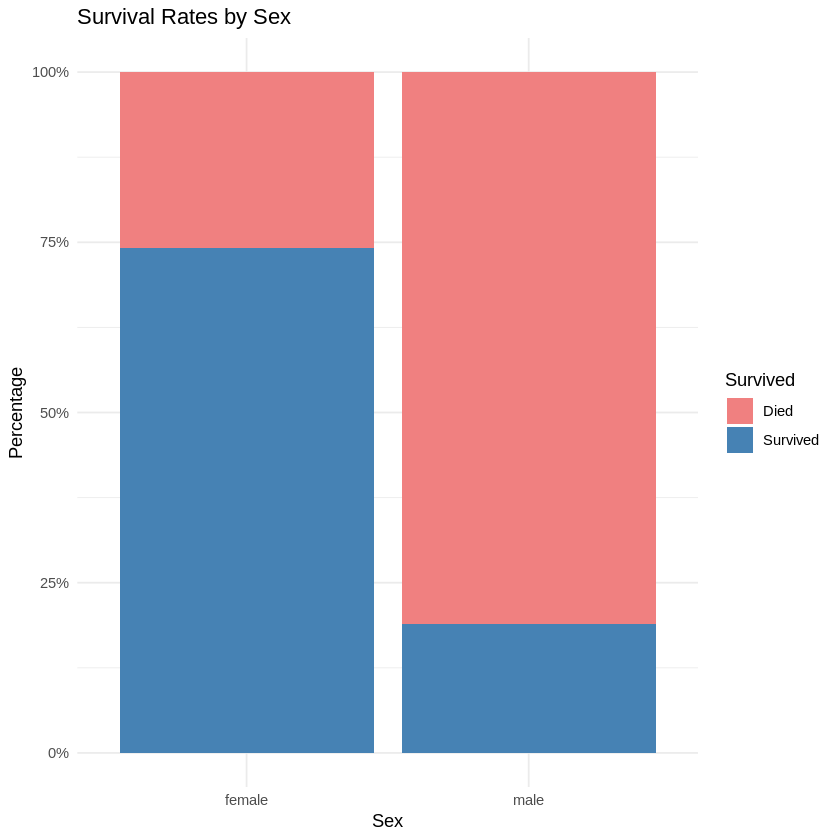

In [53]:
library(ggplot2)
library(scales)

# Bar plot of survival % by Sex
ggplot(titanic_train, aes(x = Sex, fill = Survived)) +
  geom_bar(position = "fill") +
  scale_y_continuous(labels = percent_format()) +
scale_fill_manual(values = c("Died" = "lightcoral", "Survived" = "steelblue"),
                  name = "Survived" ,
                  labels = c("Died", "Survived"))+
  labs(title = "Survival Rates by Sex",
       x = "Sex",
       y = "Percentage") +
  theme_minimal()


### 🧾 Interpretation: Survival and Sex

The contingency table shows:

- Among passengers who **did not survive**, 468 were men and only 81 were women.
- Among those who **survived**, 233 were women versus just 109 men.

The Chi-squared test confirms that the association between `Sex` and `Survived` is **highly statistically significant**  
(*X² = 260.72, df = 1, p < 0.001*).

In percentages:
- Among the deceased: **81.1% were male**, only **25.8% were female**.
- Among the survivors: **74.2% were female**, only **18.9% were male**.

👉 This strong association suggests that `Sex` will likely be one of the first splitting variables in the CHAID decision tree.


## 5. 👨‍👩‍👧 **Family Onboard Indicators: Traveling Alone vs. With Family**

In this section, we explore two variables in the dataset:

- `SibSp`: Number of siblings or spouses aboard
- `Parch`: Number of parents or children aboard

These variables can tell us whether a passenger was **accompanied by family** or **traveling alone** — a factor that may influence survival.

We will:
- Visualize the distribution of family members aboard
- Create a new feature called `Alone` to indicate whether the passenger had **no family on board**
- Analyze the relationship between traveling alone and survival, using percentages and a Chi-squared test



  0   1   2   3   4   5   8 
608 209  28  16  18   5   7 


  0   1   2   3   4   5   6 
678 118  80   5   4   5   1 

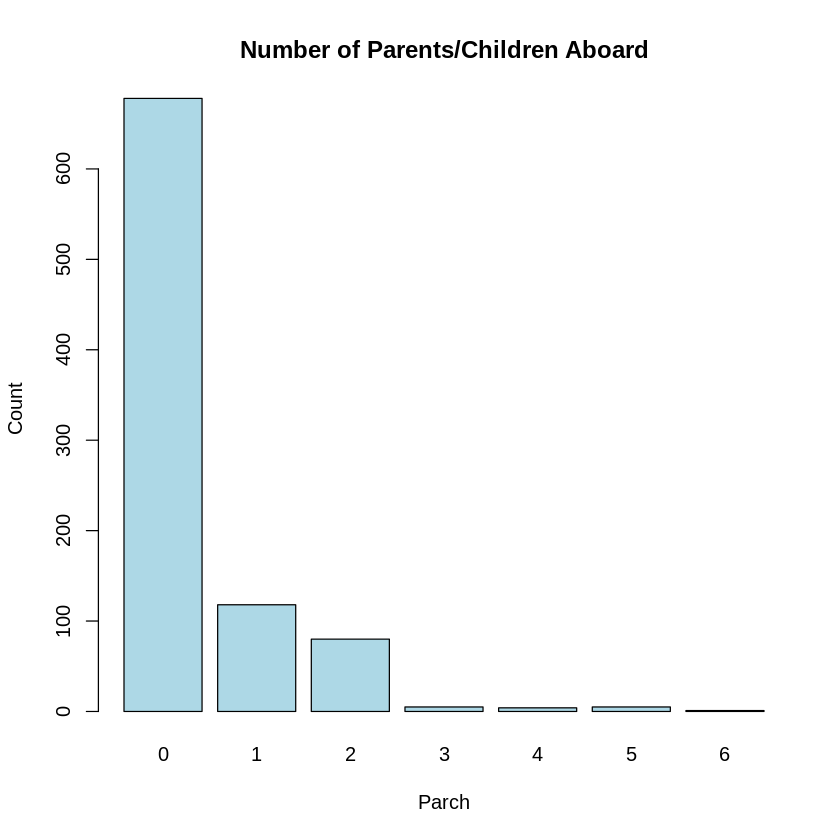

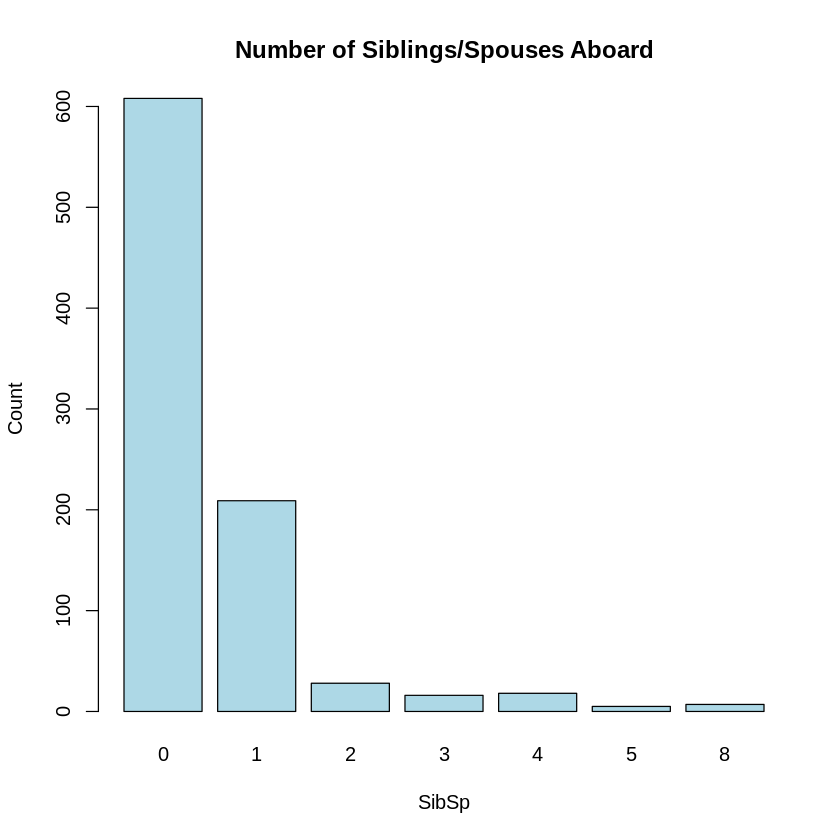

In [54]:
# 📊 Frequency tables for family aboard
table(titanic_train$SibSp)  # Number of siblings/spouses aboard
table(titanic_train$Parch)  # Number of parents/children aboard

# 📈 Barplots for family variables
barplot(
  table(titanic_train$Parch),
  main = "Number of Parents/Children Aboard",
  xlab = "Parch",
  ylab = "Count",
  col = "lightblue"
)

barplot(
  table(titanic_train$SibSp),
  main = "Number of Siblings/Spouses Aboard",
  xlab = "SibSp",
  ylab = "Count",
  col = "lightblue"
)

In [55]:
# 👤 Create new variable: Alone vs Not Alone
titanic_train$Alone <- ifelse(
  titanic_train$Parch == 0 & titanic_train$SibSp == 0,
  1,  # Alone
  0   # Not Alone
)

# Ensure Survived is a factor with specified levels and labels
titanic_train$Alone <- factor(titanic_train$Alone, levels = c(0, 1), labels = c("Not alone", "Alone"))

table(titanic_train$Alone)

# 📊 Survival proportions by Alone status
surv_alone_tab <- prop.table(table(titanic_train$Survived, titanic_train$Alone), margin = 2) * 100
print(round(surv_alone_tab, 1))

# 🧪 Chi-squared test: Is being alone associated with survival?
chisq.test(titanic_train$Survived, titanic_train$Alone)


Not alone     Alone 
      354       537 

          
           Not alone Alone
  Died          49.4  69.6
  Survived      50.6  30.4



	Pearson's Chi-squared test with Yates' continuity correction

data:  titanic_train$Survived and titanic_train$Alone
X-squared = 36.001, df = 1, p-value = 1.973e-09


### 📄 Interpretation: Does Traveling Alone Affect Survival?

We examined two variables — `SibSp` (siblings/spouses aboard) and `Parch` (parents/children aboard) — and created a new variable, `Alone`, to indicate whether passengers were traveling without any family.

#### 🧮 Family Size Distributions:
- Most passengers had **no siblings/spouses (608)** and **no parents/children (678)** on board.
- A small number had large families (e.g., 8 siblings/spouses or 6 parents/children), but these are rare.

#### 👤 Traveling Alone and Survival:
- Among passengers **traveling alone**, **69.6% died**, and only **30.4% survived**.
- In contrast, among those **with family**, survival was roughly **50/50**.

#### 📊 Statistical Test:
A **Chi-squared test** confirms that the association between survival and traveling alone is **highly significant**:
- χ² = 36.0, df = 1, *p* < 0.000000002  
- This means the observed difference is **very unlikely to be due to chance**.

#### 💡 Conclusion:
> Traveling alone was associated with a **significantly lower chance of survival**.  
> Social or logistical factors (like being helped or prioritized by family) may have influenced this pattern.

This new feature `Alone` is a valuable predictor and could improve our model’s performance.

> 🔍 **Try it yourself**
>
> Now that we've seen that traveling alone influences survival, let's take it a step further:
>
> **Try exploring `Alone` and `Sex` together.**  
> What patterns do you see? Who was more likely to travel alone? What might that tell us?


## 6. **CHAID Decision Tree**
### 🌳 Building Our First CHAID Tree

Now let’s fit our first CHAID decision tree model using just two categorical predictors:  
- `Sex` (male or female)  
- `Embarked` (port of boarding: Southampton, Cherbourg, or Queenstown)

CHAID selects splits based on statistical significance (via Chi-squared tests), not just accuracy.  
This makes it especially **transparent** and **interpretable** — perfect for understanding how decisions are made.

🧠 What to expect:
- CHAID will evaluate which variable explains survival **best** and use it for the first split.
- It will then examine the **next most significant variable**, if it adds explanatory power.
- The algorithm stops when **no further statistically significant splits** can be made.

Let’s see what kind of rules emerge!



Model formula:
Survived ~ Sex + Embarked

Fitted party:
[1] root
|   [2] Sex in female
|   |   [3] Embarked in , C: Survived (n = 75, err = 12.0%)
|   |   [4] Embarked in Q, S: Survived (n = 239, err = 30.1%)
|   [5] Sex in male
|   |   [6] Embarked in , C: Died (n = 95, err = 30.5%)
|   |   [7] Embarked in Q, S: Died (n = 482, err = 16.6%)

Number of inner nodes:    3
Number of terminal nodes: 4


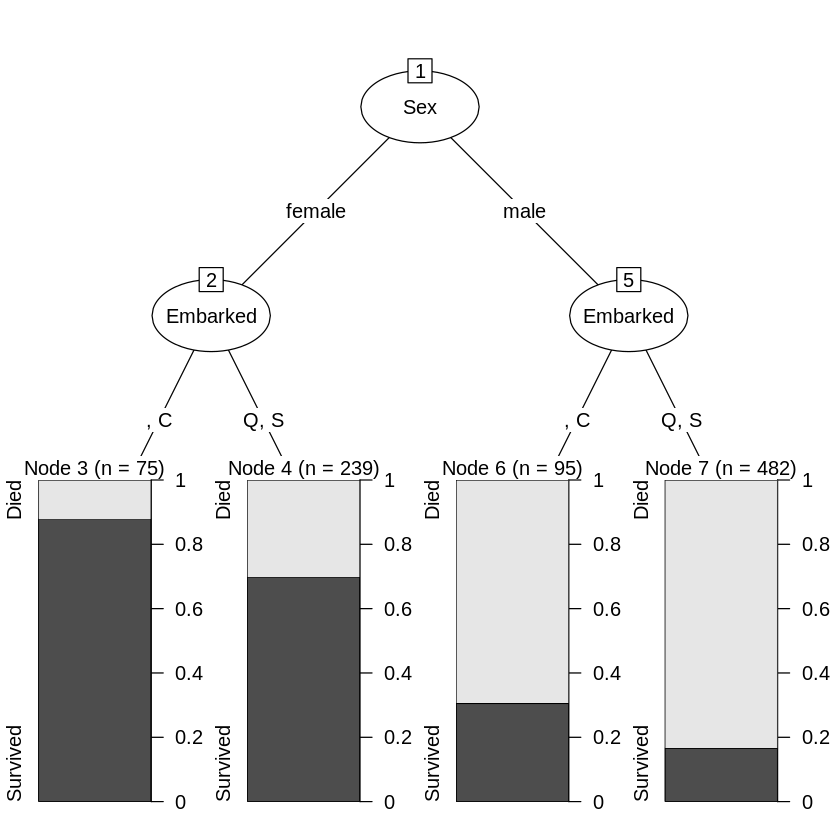

In [56]:
# @title
# 🌳 Fit CHAID model
chaidtitanic <- chaid(Survived ~ Sex + Embarked, data = titanic_train)

# 🖨️ View structure
print(chaidtitanic)

# ✅ Plot with larger size and built-in title
# Use graphics settings for larger text and compact layout
par(mar = c(1, 1, 2, 1))     # Margins
par(cex = 1.2)               # Text scaling
par(mfrow = c(1, 1))         # Reset layout

# Plot the CHAID tree with embedded main title
plot(chaidtitanic,
     uniform = TRUE,
     compress = TRUE,
     margin = 0.1,
     main = "CHAID Decision Tree: Sex + Embarked")


### 🌳 Interpretation of CHAID Tree (Sex + Embarked)

- The CHAID tree splits first on **Sex**, confirming it as the most discriminative variable for survival.
- Among **females**, survival rates were notably higher for those who embarked in **Cherbourg** or whose port of embarkation was missing.
  - This likely reflects **first-class women**, as many wealthy passengers boarded in Cherbourg.
- Among **males**, survival was lowest for those who embarked in **Queenstown or Southampton**.
  - This makes sense historically: **third-class male passengers**, many of whom boarded in **Southampton**, were placed in the **lowest decks**, making escape more difficult when the ship sank.
  - CHAID merges Queenstown and Southampton — it sees no real difference in survival patterns. That’s smart modeling.

> 📌 *This tree is not only statistically sound but also reflects key socioeconomic and structural realities of the Titanic's passenger hierarchy.*

By connecting data-driven splits with historical facts, we better understand **why** certain patterns appear — a critical goal in data science education.



## 7. 🔁 **Refine CHAID Model with Pclass**

Now let’s improve our model by adding another key variable: **`Pclass`**, which reflects passenger class (1st, 2nd, or 3rd).

Since `Pclass` is ordinal — higher numbers indicate lower-class tickets — we convert it into an ordered factor (`PclassF`) so that CHAID treats it accordingly.

Why include it?

- `Pclass` captures both **socioeconomic status** and **location on the ship**, two factors strongly related to survival.
- It may explain differences **within groups** already split by `Sex` and `Embarked`.

Let’s see how the tree structure changes and whether survival patterns become more nuanced.



Model formula:
Survived ~ Sex + Embarked + PclassF

Fitted party:
[1] root
|   [2] Sex in female
|   |   [3] PclassF in 1, 2: Survived (n = 170, err = 5.3%)
|   |   [4] PclassF in 3
|   |   |   [5] Embarked in , C, Q: Survived (n = 56, err = 30.4%)
|   |   |   [6] Embarked in S: Died (n = 88, err = 37.5%)
|   [7] Sex in male
|   |   [8] PclassF in 1: Died (n = 122, err = 36.9%)
|   |   [9] PclassF in 2, 3: Died (n = 455, err = 14.1%)

Number of inner nodes:    4
Number of terminal nodes: 5


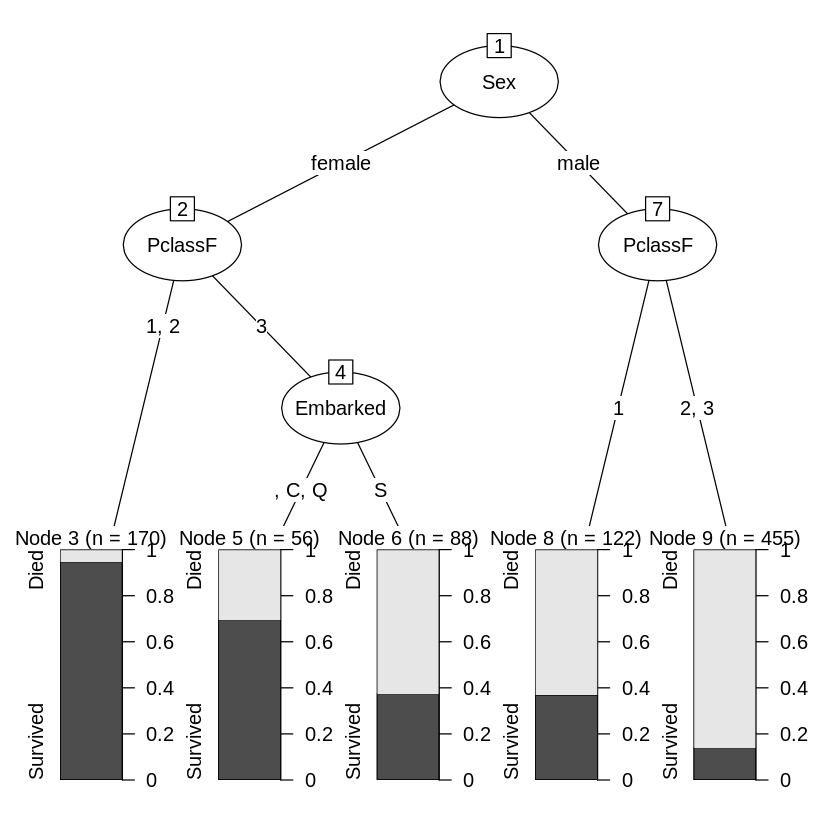

In [57]:
titanic_train$PclassF <- factor(titanic_train$Pclass, order=TRUE)
chaidtitanic <- chaid(Survived ~ Sex + Embarked + PclassF, data = titanic_train)
print(chaidtitanic)
plot(chaidtitanic)

## 8. **CHAID Extended with Parch and SibSp**

Let’s now extend our CHAID model by including information about whether passengers were traveling with family:

- `Parch`: Number of parents or children aboard
- `SibSp`: Number of siblings or spouses aboard

We’ve already seen earlier that **traveling alone was linked to lower survival rates**.  
Now we give the model access to that same information — directly.

We’ll convert these variables into **ordered factors** to reflect their natural numeric structure, and then build a new CHAID tree.

Let’s see if these social and relational variables help CHAID generate even more insightful decision rules.



Model formula:
Survived ~ Sex + Embarked + PclassF + ParchF + SibSpF

Fitted party:
[1] root
|   [2] Sex in female
|   |   [3] PclassF in 1, 2: Survived (n = 170, err = 5.3%)
|   |   [4] PclassF in 3
|   |   |   [5] Embarked in , C, Q: Survived (n = 56, err = 30.4%)
|   |   |   [6] Embarked in S: Died (n = 88, err = 37.5%)
|   [7] Sex in male
|   |   [8] PclassF in 1: Died (n = 122, err = 36.9%)
|   |   [9] PclassF in 2, 3
|   |   |   [10] ParchF in 0: Died (n = 385, err = 11.4%)
|   |   |   [11] ParchF in 1, 2, 3, 4, 5, 6
|   |   |   |   [12] SibSpF in 0, 1, 2: Died (n = 46, err = 41.3%)
|   |   |   |   [13] SibSpF in 3, 4, 5, 8: Died (n = 24, err = 4.2%)

Number of inner nodes:    6
Number of terminal nodes: 7


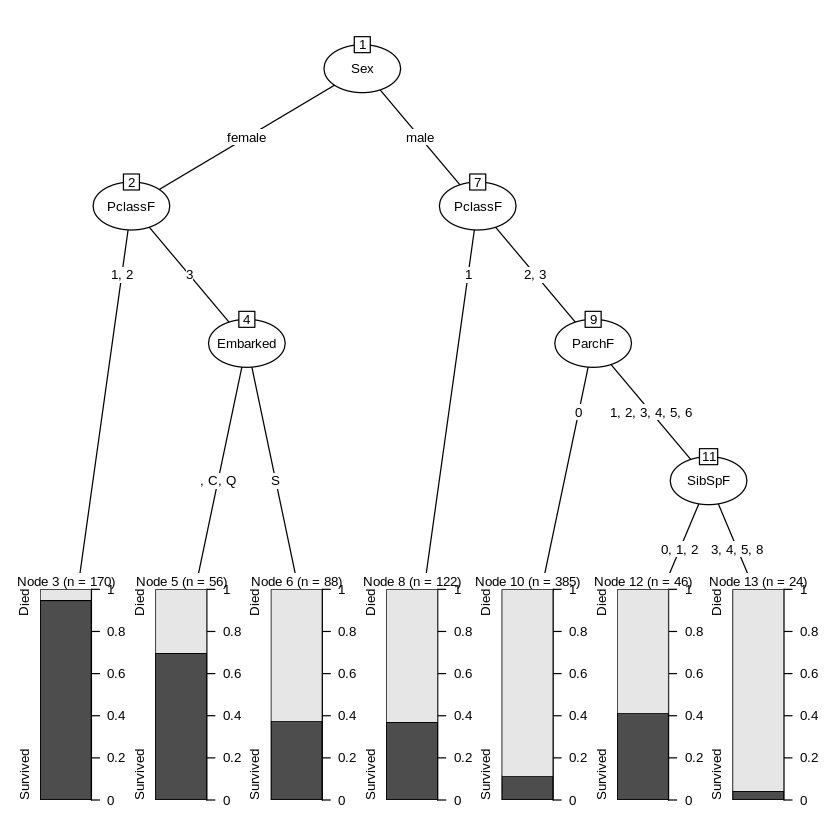

In [58]:
# Convert Parch and SibSp to ordered factors
titanic_train$ParchF <- factor(titanic_train$Parch, order = TRUE)
titanic_train$SibSpF <- factor(titanic_train$SibSp, order = TRUE)

# Fit extended CHAID model
chaidtitanic3 <- chaid(Survived ~ Sex + Embarked + PclassF + ParchF + SibSpF, data = titanic_train)

# Print and plot
print(chaidtitanic3)
plot(chaidtitanic3, compress = TRUE, uniform = TRUE, gp = gpar(fontsize = 8))

## 9. **Predict on Titanic Test Set**
## 🧪 Preparing the Test Dataset for Prediction

Before we can use our trained CHAID model to make predictions, we need to ensure the **test dataset is properly prepared**:

- We load the test data from GitHub (this is the same structure used in the Kaggle competition).
- Just like in the training data, we:
  - Convert `Pclass` into an **ordered factor** (`PclassF`)
  - Convert `Parch` and `SibSp` into **ordered factors** as well
  - Fix a small anomaly: one record has `Parch = 9`, which didn’t appear in the training set — we replace it with 6

This step is essential:  
> The test data must match the **structure and format** of the training data — otherwise, the model won't know how to interpret the variables.


In [59]:
# 📥 Load Titanic test dataset from GitHub
titanic_test <- read.csv(
  "https://raw.githubusercontent.com/JonPaulBIlbao/ML-Finance-DBS/Machine-Learning-in-Finance-DBS/decision_trees/test.csv",
  stringsAsFactors = TRUE  # Automatically convert character columns to factors
)

# 🔁 Convert Pclass to an ordered factor (1st > 2nd > 3rd)
titanic_test$PclassF <- factor(titanic_test$Pclass, order = TRUE)

# ⚠️ Fix anomalous value: change Parch = 9 to 6 (no such value in training set)
titanic_test$Parch <- ifelse(titanic_test$Parch == 9, 6, titanic_test$Parch)

# 🔁 Convert Parch and SibSp into ordered factors (to match training model)
titanic_test$ParchF <- factor(titanic_test$Parch, order = TRUE)
titanic_test$SibSpF <- factor(titanic_test$SibSp, order = TRUE)

# 🔎 Quick check of structure and missing values
summary(titanic_test)


  PassengerId         Pclass     
 Min.   : 892.0   Min.   :1.000  
 1st Qu.: 996.2   1st Qu.:1.000  
 Median :1100.5   Median :3.000  
 Mean   :1100.5   Mean   :2.266  
 3rd Qu.:1204.8   3rd Qu.:3.000  
 Max.   :1309.0   Max.   :3.000  
                                 
                                        Name         Sex           Age       
 Abbott, Master. Eugene Joseph            :  1   female:152   Min.   : 0.17  
 Abelseth, Miss. Karen Marie              :  1   male  :266   1st Qu.:21.00  
 Abelseth, Mr. Olaus Jorgensen            :  1                Median :27.00  
 Abrahamsson, Mr. Abraham August Johannes :  1                Mean   :30.27  
 Abrahim, Mrs. Joseph (Sophie Halaut Easu):  1                3rd Qu.:39.00  
 Aks, Master. Philip Frank                :  1                Max.   :76.00  
 (Other)                                  :412                NA's   :86     
     SibSp            Parch            Ticket         Fare        
 Min.   :0.0000   Min.   :0.000   PC 

## 🎯 Predicting Survival on the Test Set

Now that the test data is ready, we can use our extended CHAID model (`chaidtitanic3`) to predict survival.

The model assigns each passenger in the test set to a **terminal node** in the tree and predicts their outcome (Survived or Died) based on the rules learned from the training data.

Let’s apply the model and inspect predictions by gender to see how well it generalizes.

In [60]:
# 🧠 Apply the trained CHAID model to the test dataset
titanic_test$SurvivedP <- predict(chaidtitanic3, titanic_test)

# 📊 Cross-tabulate predicted survival by Sex
# This gives us a quick overview of prediction patterns across genders
table(titanic_test$Sex, titanic_test$SurvivedP)

        
         Died Survived
  female   41      111
  male    266        0

> 🤔 **Model Bias or Historical Reality?**
>
> Our CHAID model predicts that **no men in the test set survived** — a stark, disappointing result.
>
> But this actually reflects two things:
> - The **harsh survival patterns** in the Titanic disaster: survival rates among men, especially in lower classes, were very low.
> - The **rigid nature of CHAID**: it creates clear rules, but may overgeneralize when the data is imbalanced.
>
> This highlights an important lesson: **interpretable models like CHAID are transparent, but not always nuanced.**  
> In contrast, probabilistic models (like logistic regression or random forest) can capture uncertainty better — but are harder to explain.
